In [1]:
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from torch.cuda.amp import GradScaler,autocast
from torchsummary import summary

In [2]:
device = torch.device('cuda'if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
transforms_train = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

transforms_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [4]:
train_data = datasets.ImageFolder(root = 'Deep learning Data/New Plant Diseases Dataset(Augmented)/train',transform = transforms_train)
test_data = datasets.ImageFolder(root = 'Deep learning Data/New Plant Diseases Dataset(Augmented)/valid',transform = transforms_test)

In [5]:
train_loader = DataLoader(train_data, batch_size = 64, shuffle = True,num_workers = 4,pin_memory = True,persistent_workers = True,drop_last = True)
test_loader = DataLoader(test_data, batch_size = 64,num_workers = 4,pin_memory = True,persistent_workers = True)

In [6]:
mobilenet = torchvision.models.mobilenet_v2('MobileNet_V2_Weights.DEFAULT')
print(mobilenet)

C:\Users\amsha\PycharmProjects\PythonProject2\.venv\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [7]:
for p in mobilenet.parameters():
    p.requires_grad = False

for p in mobilenet.classifier.parameters():
    p.requires_grad = True

mobilenet.classifier[1] = nn.Linear(1280,38)

In [8]:
summary(mobilenet.cuda(),(3,224,224))

Layer (type:depth-idx)                             Output Shape              Param #
├─Sequential: 1-1                                  [-1, 1280, 7, 7]          --
|    └─Conv2dNormActivation: 2-1                   [-1, 32, 112, 112]        --
|    |    └─Conv2d: 3-1                            [-1, 32, 112, 112]        (864)
|    |    └─BatchNorm2d: 3-2                       [-1, 32, 112, 112]        (64)
|    |    └─ReLU6: 3-3                             [-1, 32, 112, 112]        --
|    └─InvertedResidual: 2-2                       [-1, 16, 112, 112]        --
|    |    └─Sequential: 3-4                        [-1, 16, 112, 112]        (896)
|    └─InvertedResidual: 2-3                       [-1, 24, 56, 56]          --
|    |    └─Sequential: 3-5                        [-1, 24, 56, 56]          (5,136)
|    └─InvertedResidual: 2-4                       [-1, 24, 56, 56]          --
|    |    └─Sequential: 3-6                        [-1, 24, 56, 56]          (8,832)
|    └─InvertedRe

Layer (type:depth-idx)                             Output Shape              Param #
├─Sequential: 1-1                                  [-1, 1280, 7, 7]          --
|    └─Conv2dNormActivation: 2-1                   [-1, 32, 112, 112]        --
|    |    └─Conv2d: 3-1                            [-1, 32, 112, 112]        (864)
|    |    └─BatchNorm2d: 3-2                       [-1, 32, 112, 112]        (64)
|    |    └─ReLU6: 3-3                             [-1, 32, 112, 112]        --
|    └─InvertedResidual: 2-2                       [-1, 16, 112, 112]        --
|    |    └─Sequential: 3-4                        [-1, 16, 112, 112]        (896)
|    └─InvertedResidual: 2-3                       [-1, 24, 56, 56]          --
|    |    └─Sequential: 3-5                        [-1, 24, 56, 56]          (5,136)
|    └─InvertedResidual: 2-4                       [-1, 24, 56, 56]          --
|    |    └─Sequential: 3-6                        [-1, 24, 56, 56]          (8,832)
|    └─InvertedRe

In [9]:
epochs = 10
lossfunc = nn.CrossEntropyLoss()
losses = torch.zeros(epochs)
mobilenet.to(device)
scaler = GradScaler()
trainAcc = []
testAcc = []
optimizer = torch.optim.Adam(mobilenet.parameters(),lr=0.001)
for epoch in range(epochs):
    batchAcc = []
    batchLoss = []
    start = time.time()
    mobilenet.train()
    for X,y in train_loader:
        X = X.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        with autocast():
            output = mobilenet(X)
            loss = lossfunc(output,y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        batchLoss.append(loss.item())
        acc = 100*(torch.argmax(output,1)==y).float().mean().item()
        batchAcc.append(acc)
    end = time.time()
    epoch_time = end-start
    losses[epoch] = np.mean(batchLoss)
    trainAcc.append(np.mean(batchAcc))
    all_pred = []
    all_label = []
    with torch.no_grad():
        mobilenet.eval()
        acc_test = []
        for X,y in test_loader:
            X = X.to(device)
            y = y.to(device)
            output = mobilenet(X)
            preds = torch.argmax(output,1)
            all_pred.extend(preds.cpu().numpy())
            all_label.extend(y.cpu().numpy())
            acc = 100*(torch.argmax(output,1)==y).float().mean().item()
            acc_test.append(acc)
        testAcc.append(np.mean(acc_test))

    if epoch % 5 == 0:
        print(f'epoch:{epoch} , loss:{losses[epoch]} , epoch_time:{epoch_time} ')



C:\Users\amsha\AppData\Local\Temp\ipykernel_20660\865030865.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\amsha\AppData\Local\Temp\ipykernel_20660\865030865.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


epoch:0 , loss:1.1589879989624023 , epoch_time:241.3232810497284 
epoch:5 , loss:0.5295129418373108 , epoch_time:55.41656684875488 


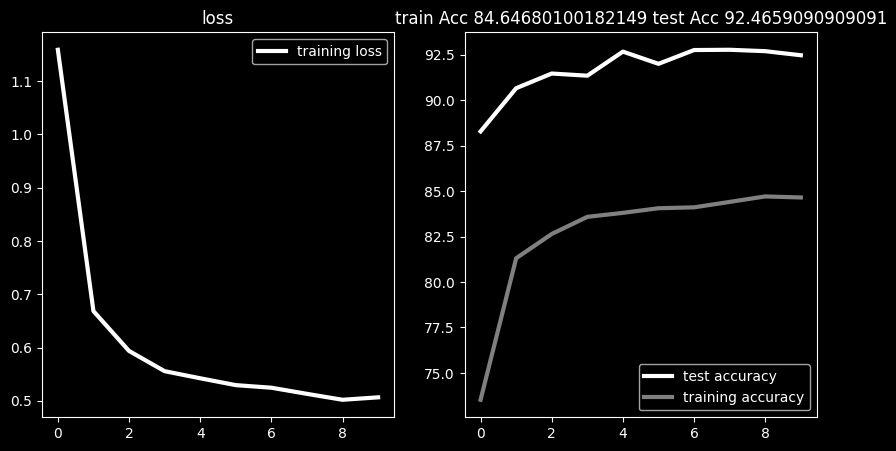

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(losses, 'white', lw=3, label='training loss')
ax[0].set_title('loss')
ax[0].legend()
ax[1].plot(testAcc, 'white', lw=3, label='test accuracy')
ax[1].plot(trainAcc, 'gray', lw=3, label='training accuracy')
ax[1].set_title(f'train Acc {trainAcc[-1]} test Acc {testAcc[-1]}')
ax[1].legend()
plt.show()

<Figure size 2500x2500 with 0 Axes>

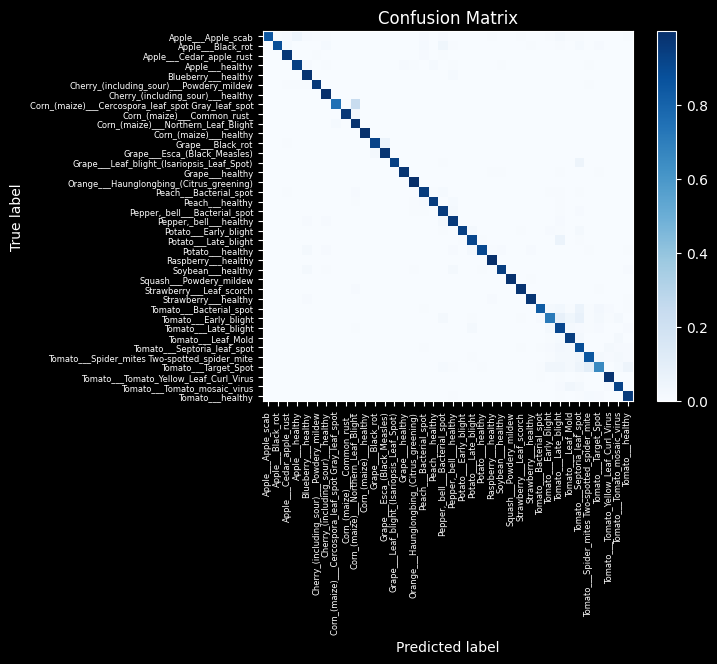

In [11]:
cm = confusion_matrix(
    all_label,
    all_pred,
    normalize= 'true'
)
plt.figure(figsize = (25,25))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_data.classes
)
disp.plot(cmap='Blues',xticks_rotation=90,include_values=False)
plt.title('Confusion Matrix')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.show()